# Clase 3 · Análisis exploratorio de datos: descripción de una variable

**INF-396 Introducción a la Ciencia de Datos** · Universidad Técnica Federico Santa María

Objetivos de la sesión: describir una variable con sus tres miradas (centro, dispersión y forma), primero con iris y luego con la EOD, y revisar la calidad de los datos antes de analizarlos.

## 1. Preparación

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

# Gráficos más nítidos en pantallas de alta resolución
%config InlineBackend.figure_format = "retina"


In [2]:
BASE = "datos/eod_stgo/"  # los datos vienen incluidos al clonar el repositorio
# Para correrlo sin clonar (por ejemplo en Colab):
# BASE = ("https://raw.githubusercontent.com/daniopitz/cienciadatos/"
#         "main/datos/eod_stgo/")

In [3]:
# Los archivos de la EOD separan columnas con ";" y usan coma decimal.
# low_memory=False lee el archivo completo antes de decidir el tipo de
# cada columna, y evita un aviso de tipos mezclados.
viajes = pd.read_csv(BASE + "viajes.csv", sep=";", decimal=",", low_memory=False)

print(viajes.shape)
viajes.head()

(113591, 35)


,Hogar,Persona,Viaje,Etapas,ComunaOrigen,ComunaDestino,SectorOrigen,SectorDestino,ZonaOrigen,ZonaDestino,...,TiempoMedio,Periodo,MinutosDespues,CuadrasDespues,FactorLaboralNormal,FactorSabadoNormal,FactorDomingoNormal,FactorLaboralEstival,FactorFindesemanaEstival,CodigoTiempo
0,173431,17343102,1734310202,1,94.0,94.0,2.0,2.0,400,407,...,3.0,6.0,6.0,1.0,1.000000,NaN,NaN,NaN,NaN,0.0
1,173441,17344101,1734410101,2,94.0,71.0,2.0,3.0,407,307,...,4.0,5.0,5.0,1.0,1.127220,NaN,NaN,NaN,NaN,0.0
2,173441,17344101,1734410102,2,71.0,94.0,3.0,2.0,307,407,...,3.0,5.0,10.0,2.0,1.127220,NaN,NaN,NaN,NaN,0.0
3,173441,17344103,1734410301,2,94.0,91.0,2.0,3.0,407,437,...,2.0,5.0,10.0,2.0,1.127220,NaN,NaN,NaN,NaN,0.0
4,173441,17344103,1734410302,2,91.0,94.0,3.0,2.0,437,407,...,5.0,4.0,10.0,2.0,1.052764,NaN,NaN,NaN,NaN,0.0


In [4]:
hogares = pd.read_csv(BASE + "Hogares.csv", sep=";", decimal=",", low_memory=False)

print(hogares.shape)
hogares.head()

(18264, 21)


,Hogar,Sector,Zona,Comuna,DirCoordX,DirCoordY,Fecha,DiaAsig,TipoDia,Temporada,...,NumVeh,NumBicAdulto,NumBicNino,Propiedad,MontoDiv,ImputadoDiv,MontoArr,ImputadoArr,IngresoHogar,Factor
0,100010,7,786,BUIN,335180.8019,6266420.975,14-04-2013,domingo,2,1,...,1,1,0,2,53000.0,0,100000,0,450845,136.393738
1,100020,7,785,BUIN,338410.2114,6265607.141,10-04-2013,miércoles,1,1,...,1,3,0,1,NaN,0,120000,0,1019369,73.843597
2,100030,7,791,BUIN,327863.8248,6257800.086,23-08-2013,viernes,1,1,...,0,0,0,3,NaN,0,70000,0,80000,180.722809
3,100041,7,791,BUIN,327864.0000,6257800.000,23-08-2013,viernes,1,1,...,0,1,0,1,NaN,0,80000,0,559259,150.379059
4,100052,7,783,BUIN,338480.8152,6267296.941,08-08-2013,jueves,1,1,...,0,0,0,1,NaN,0,117771,1,710309,122.001518


## 2. Los conceptos, con iris

iris: 150 flores de tres especies, con cuatro medidas en centímetros (Fisher, 1936). Chico y ordenado: cada resumen se puede verificar a mano.

![Las cuatro medidas de iris: largo y ancho del sépalo y del pétalo](figuras/iris_medidas.jpeg)

Viene incluido en scikit-learn, que por ser una librería de machine learning organiza sus datasets en dos partes: `iris.data`, con las variables de entrada (las cuatro medidas de cada flor), e `iris.target`, la variable **objetivo**, la que un modelo intentaría predecir. Aquí el objetivo es la especie, y viene como un arreglo de 150 enteros: 0, 1 o 2 según la flor. El orden de esos códigos está en `iris.target_names` (0 es setosa, 1 versicolor, 2 virginica).

In [5]:
from sklearn.datasets import load_iris

iris = load_iris()

# La variable objetivo, tal como llega: 150 códigos, y sus nombres
print(iris.target)
print(iris.target_names)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
['setosa' 'versicolor' 'virginica']


Se ven los tres bloques de 50: las primeras flores son 0 (setosa), luego los 1 (versicolor) y al final los 2 (virginica). Con eso armamos el DataFrame, traduciendo los códigos a nombres:

In [6]:
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [7]:
# Un diccionario traduce cada código a su nombre, con .map()
nombres = {0: "setosa", 1: "versicolor", 2: "virginica"}
iris_df["species"] = pd.Series(iris.target).map(nombres)

iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### Un primer vistazo: histogramas

Antes de calcular resúmenes, mirar. `DataFrame.hist()` dibuja el histograma de cada columna numérica del dataset en una sola figura:

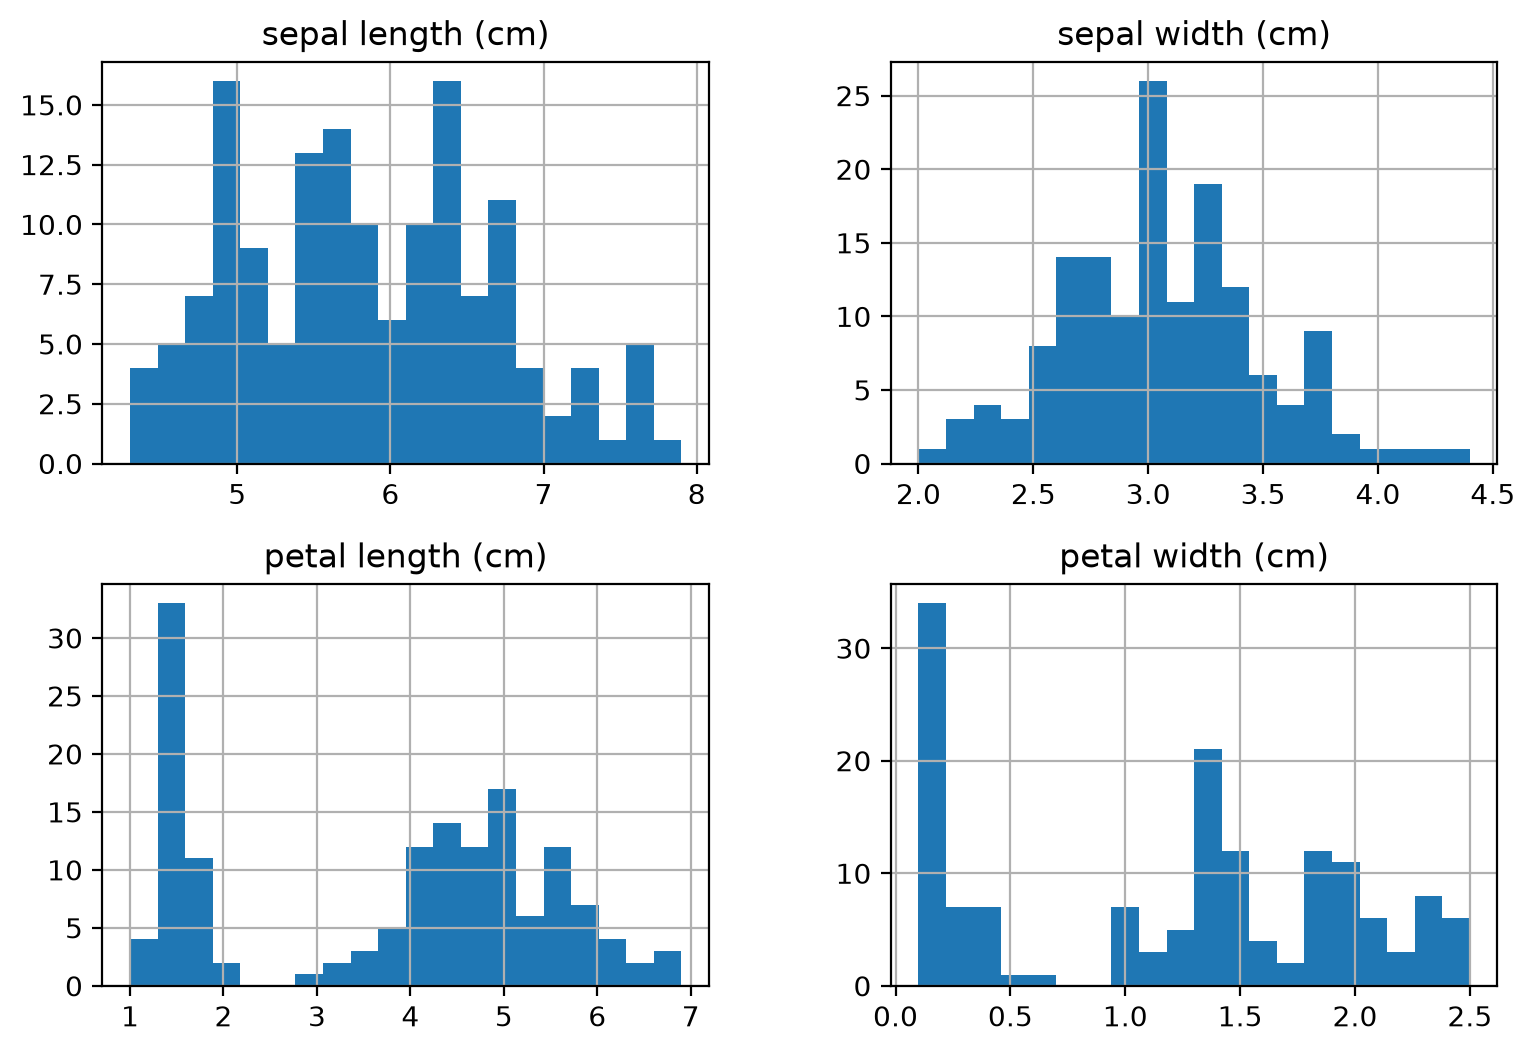

In [8]:
iris_df.hist(figsize=(9, 6), bins=20)
plt.show()

Cuatro formas distintas en una pasada: el largo y el ancho del sépalo se ven acampanados, pero el largo y el ancho del **pétalo** muestran dos grupos separados. Ese quiebre es una pista de que conviene mirar por especie; lo haremos con el boxplot.

### Frecuencia y moda

Para una variable cualitativa, el resumen básico es la frecuencia de cada categoría; la moda es la categoría más frecuente.

In [9]:
print(iris_df["species"].value_counts())



species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [10]:
print(iris_df["species"].value_counts(normalize=True) * 100)

species
setosa        33.333333
versicolor    33.333333
virginica     33.333333
Name: proportion, dtype: float64


Cincuenta de cada especie: un diseño balanceado (y una moda empatada en tres).

### Media y mediana

La media es el promedio: la suma de los valores dividida por el número de datos. La mediana es el valor central: deja el 50% de los datos a cada lado. En una distribución simétrica casi coinciden:

In [11]:
media = iris_df["sepal length (cm)"].mean()
mediana = iris_df["sepal length (cm)"].median()
# La moda también existe para cuantitativas: el valor más repetido
moda = iris_df["sepal length (cm)"].mode()[0]

print("Media:  ", round(media, 2))
print("Mediana:", mediana)
print("Moda:   ", moda)

Media:   5.84
Mediana: 5.8
Moda:    5.0


In [12]:
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


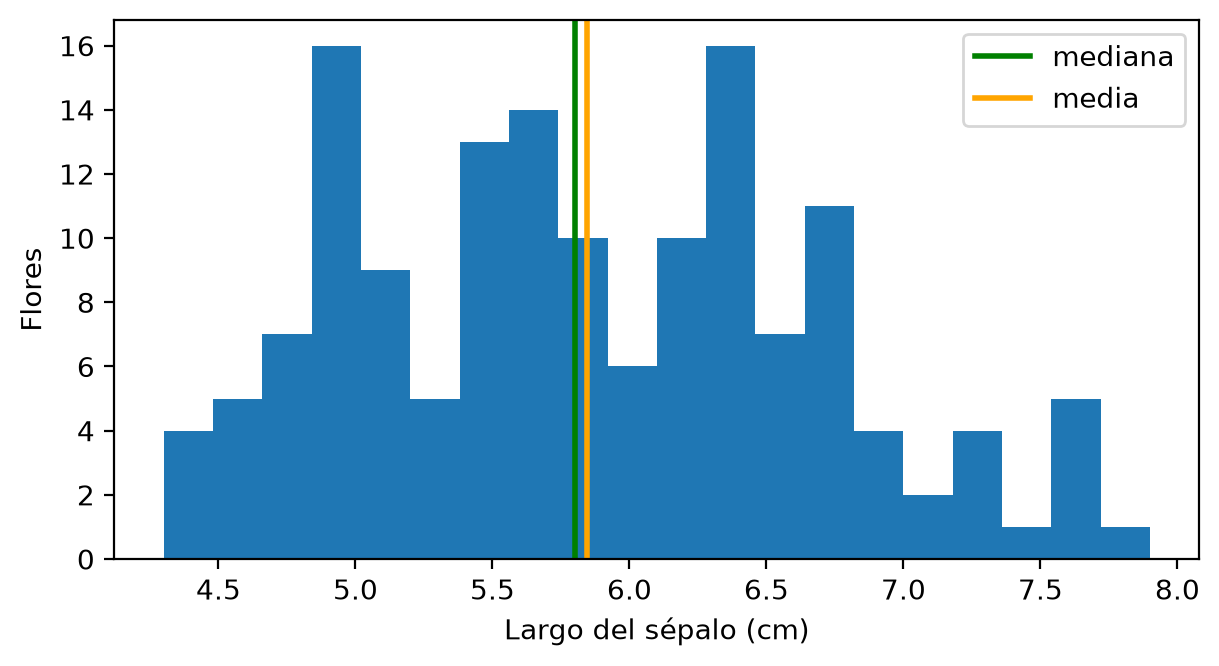

In [13]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(iris_df["sepal length (cm)"], bins=20)
# axvline dibuja una línea vertical en el valor indicado; aquí
# marca dónde caen la mediana y la media sobre el histograma
ax.axvline(mediana, color="green", lw=2, label="mediana")
ax.axvline(media, color="orange", lw=2, label="media")
ax.set_xlabel("Largo del sépalo (cm)")
ax.set_ylabel("Flores")
ax.legend()
plt.show()

### Percentiles y describe

El percentil p es el valor bajo el cual queda el p% de los datos. Los cinco números clásicos son mínimo, Q1, mediana, Q3 y máximo. `quantile` recibe proporciones entre 0 y 1, así que el percentil 25 se pide como `0.25`:

In [14]:
print(iris_df["sepal length (cm)"].quantile([0, 0.25, 0.5, 0.75, 1]))

0.00    4.3
0.25    5.1
0.50    5.8
0.75    6.4
1.00    7.9
Name: sepal length (cm), dtype: float64


In [15]:
print(iris_df["sepal length (cm)"].describe().round(2))

count    150.00
mean       5.84
std        0.83
min        4.30
25%        5.10
50%        5.80
75%        6.40
max        7.90
Name: sepal length (cm), dtype: float64


### El boxplot

El boxplot comprime esos números en un gráfico. El esquema, con tres grupos de ejemplo: la **caja** va de Q1 a Q3 (su largo es el IQR), la **línea** interior es la mediana, los **bigotes** llegan hasta el último valor que queda a menos de 1,5 veces el IQR de la caja, y los **puntos sueltos** son los valores atípicos.

![Esquema de un boxplot: caja, mediana, bigotes y atípicos](figuras/boxplot_esquema.png)

Tres centros y tres anchos distintos de un vistazo, y los valores extremos marcados como puntos. En eso rinde el boxplot: comparar grupos. Ahora con los datos reales de iris, el largo del pétalo por especie:

In [16]:
# loc filtra filas y elige una columna: antes de la coma va la
# condición sobre las filas, después la columna que queremos
setosa = iris_df.loc[iris_df["species"] == "setosa", "petal length (cm)"]
setosa

0     1.4
1     1.4
2     1.3
3     1.5
4     1.4
5     1.7
6     1.4
7     1.5
8     1.4
9     1.5
10    1.5
11    1.6
12    1.4
13    1.1
14    1.2
15    1.5
16    1.3
17    1.4
18    1.7
19    1.5
20    1.7
21    1.5
22    1.0
23    1.7
24    1.9
25    1.6
26    1.6
27    1.5
28    1.4
29    1.6
30    1.6
31    1.5
32    1.5
33    1.4
34    1.5
35    1.2
36    1.3
37    1.4
38    1.3
39    1.5
40    1.3
41    1.3
42    1.3
43    1.6
44    1.9
45    1.4
46    1.6
47    1.4
48    1.5
49    1.4
Name: petal length (cm), dtype: float64

In [17]:
setosa.describe().round(2)

count    50.00
mean      1.46
std       0.17
min       1.00
25%       1.40
50%       1.50
75%       1.58
max       1.90
Name: petal length (cm), dtype: float64

Ese es un grupo: las 50 medidas de setosa. `ax.boxplot` espera una **lista** con los datos de cada grupo, así que repetimos el mismo filtro para las otras dos especies y juntamos las tres. La versión larga, explícita:

In [18]:
setosa = iris_df.loc[iris_df["species"] == "setosa", "petal length (cm)"]
versicolor = iris_df.loc[iris_df["species"] == "versicolor", "petal length (cm)"]
virginica = iris_df.loc[iris_df["species"] == "virginica", "petal length (cm)"]

# La lista que ax.boxplot necesita: una Serie por grupo
grupos = [setosa, versicolor, virginica]
print(len(setosa), len(versicolor), len(virginica))

50 50 50


In [19]:
len(grupos)

3

Funciona, pero escribe tres veces la misma línea. La versión corta hace el mismo `loc` dentro de un for: se llama **comprensión de lista** y produce exactamente la misma lista. Con tres grupos da lo mismo cuál usar; con muchos grupos, la corta gana:

In [20]:
especies = ["setosa", "versicolor", "virginica"]
grupos = [iris_df.loc[iris_df["species"] == e, "petal length (cm)"]
          for e in especies]

print(len(grupos), "grupos")

3 grupos


¿Qué es exactamente `grupos`? Una caja con tres bolsas: la lista tiene 3 elementos, y cada elemento es una Serie de 50 medidas. `len(grupos)` cuenta las bolsas, no lo que hay dentro; si se imprime la lista completa, las tres Series salen seguidas y parece un solo chorro de 150 valores. Conviene mirar una bolsa a la vez:

In [21]:
# El primer grupo: las 50 medidas de setosa
print(len(grupos[0]))
grupos[0].head(10)

50


0    1.4
1    1.4
2    1.3
3    1.5
4    1.4
5    1.7
6    1.4
7    1.5
8    1.4
9    1.5
Name: petal length (cm), dtype: float64

El número a la izquierda de cada valor es el **índice**: la fila original de `iris_df` de donde salió. Como iris viene ordenado por especie, setosa ocupa las filas 0 a 49, versicolor 50 a 99 y virginica 100 a 149 (en datos reales los índices de un grupo salen salteados). Ojo: el índice dice de qué fila vino el dato, pero **el grupo lo define la posición en la lista**: `grupos[0]` es setosa porque `especies[0]` es "setosa". Las dos listas van en paralelo, y `zip` las empareja para recorrerlas juntas:

In [22]:
# zip entrega los pares (nombre, grupo), en orden
for nombre, g in zip(especies, grupos):
    print(nombre, "| filas", g.index.min(), "a", g.index.max(),
          "| media:", round(g.mean(), 2))

setosa | filas 0 a 49 | media: 1.46
versicolor | filas 50 a 99 | media: 4.26
virginica | filas 100 a 149 | media: 5.55


Y si un valor suelto llama la atención, su índice permite volver al DataFrame y ver la fila completa, con su especie:

In [23]:
iris_df.loc[73]

sepal length (cm)           6.1
sepal width (cm)            2.8
petal length (cm)           4.7
petal width (cm)            1.2
species              versicolor
Name: 73, dtype: object

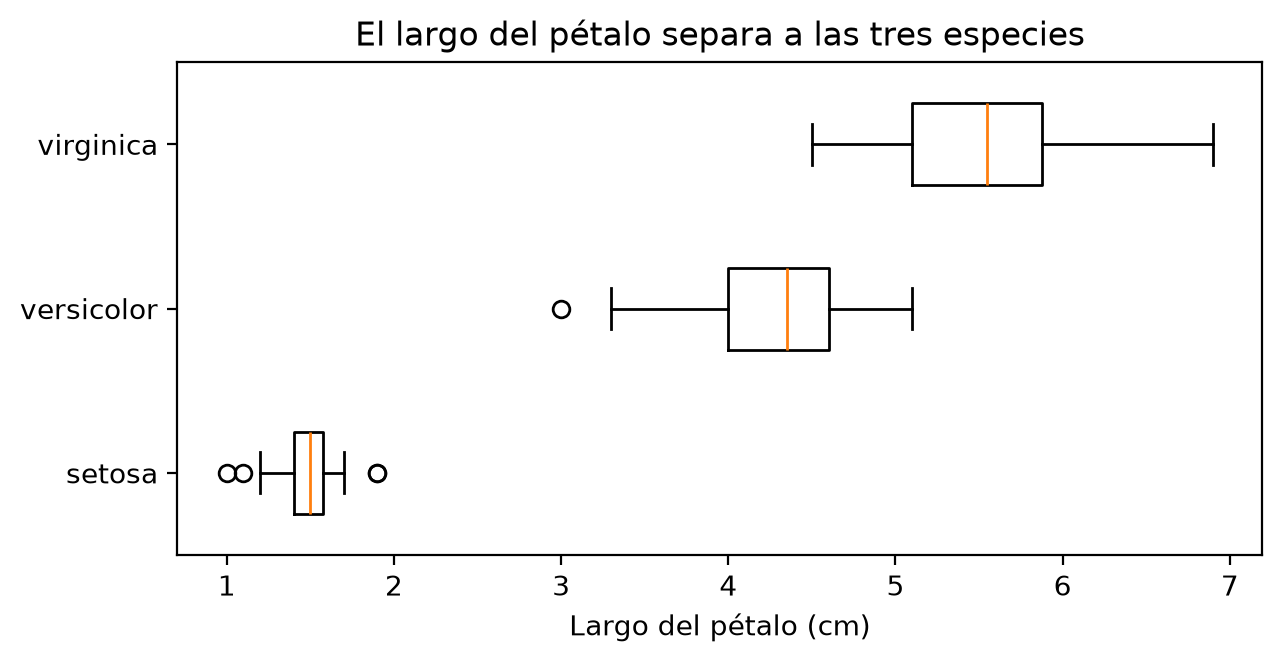

In [24]:
fig, ax = plt.subplots(figsize=(7, 3.2))
# orientation="horizontal" acuesta las cajas; tick_labels pone el
# nombre de cada grupo en el eje
ax.boxplot(grupos, orientation="horizontal", tick_labels=especies, widths=0.5)
ax.set_xlabel("Largo del pétalo (cm)")
ax.set_title("El largo del pétalo separa a las tres especies")
plt.show()

## 3. Los conceptos, en la EOD

Los mismos resúmenes, ahora en datos reales. Primero el centro de la duración de los viajes:

In [25]:
tv = viajes["TiempoViaje"]

print("Media:  ", round(tv.mean(), 1), "minutos")
print("Mediana:", tv.median(), "minutos")
# mode() devuelve una Serie, porque puede haber empates; el [0]
# toma el primer valor
print("Moda:   ", tv.mode()[0], "minutos")

Media:   36.9 minutos
Mediana: 30.0 minutos
Moda:    30.0 minutos


### La media, con factor de expansión

Esa media describe la **muestra**. Como vimos en la clase 1, cada viaje representa a un número distinto de viajes de la ciudad: su factor de expansión, que en la tabla de viajes viene por tipo de día. Para que el resumen hable de Santiago, cada viaje debe pesar según su factor. Eso es una media ponderada: la suma de (valor por peso), dividida por la suma de los pesos:

In [26]:
# Los viajes de día laboral en temporada normal: los que tienen
# ese factor
datos = viajes[["TiempoViaje", "FactorLaboralNormal"]].dropna()
tiempo = datos["TiempoViaje"]
factor = datos["FactorLaboralNormal"]
print("Viajes de día laboral:", len(datos))



Viajes de día laboral: 78595


In [27]:
# En la media ponderada cada viaje aporta según su peso:
# la suma de (valor por peso), dividida por la suma de los pesos
media_ponderada = (tiempo * factor).sum() / factor.sum()

print("Media de la muestra:", round(tiempo.mean(), 1), "minutos")
print("Media ponderada:    ", round(media_ponderada, 1), "minutos")

Media de la muestra: 37.2 minutos
Media ponderada:     34.7 minutos


La media ponderada queda 2,5 minutos bajo la simple: los viajes sobre-representados en la muestra son más largos que lo que pesan en la ciudad. Aquí la diferencia es chica; en otras variables puede no serlo. La regla: cuando la conclusión es sobre la ciudad, se pondera.

Los dos casos se pueden comparar en una sola figura: `ax.hist` también acepta `weights`, así que dibujamos el histograma de la muestra y el ponderado juntos, con ambas medias marcadas:

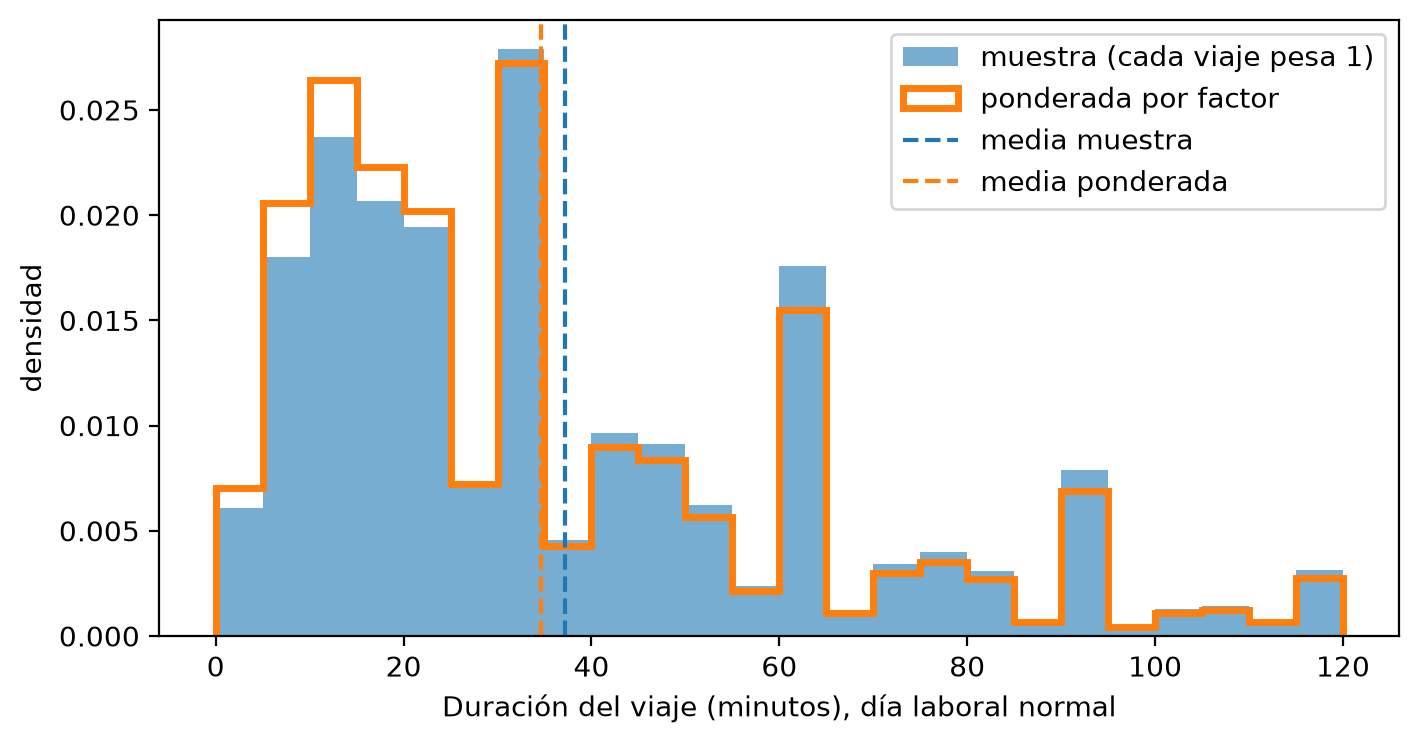

In [28]:
bins = np.arange(0, 125, 5)

fig, ax = plt.subplots(figsize=(8, 4))
# density=True normaliza ambas alturas, para que sean comparables
ax.hist(tiempo, bins=bins, density=True, alpha=0.6,
        label="muestra (cada viaje pesa 1)")
# El mismo histograma, pero cada viaje aporta su factor
ax.hist(tiempo, bins=bins, density=True, weights=factor,
        histtype="step", lw=2.5, label="ponderada por factor")
ax.axvline(tiempo.mean(), ls="--", color="C0",
           label="media muestra")
ax.axvline(media_ponderada, ls="--", color="C1",
           label="media ponderada")
ax.set_xlabel("Duración del viaje (minutos), día laboral normal")
ax.set_ylabel("densidad")
ax.legend()
plt.show()

La ponderación sube los viajes cortos y baja los largos; por eso la media ponderada cae.

### ¿Qué es la densidad del eje?

El eje vertical dice "densidad" y no "viajes" por el `density=True`: las alturas se reescalan para que el área total de las barras sea 1, y así las dos distribuciones se comparan por su **forma**, aunque una pese más que la otra. La altura no es un porcentaje: es proporción **por minuto**, y se lee multiplicando por el ancho del tramo. Un cálculo rápido con el tramo de 25 a 30 minutos:

In [29]:
# La condición produce una columna de True y False
condicion = (tiempo >= 25) & (tiempo < 30)
condicion.head()

0    False
1    False
2    False
3    False
4    False
Name: TiempoViaje, dtype: bool

Y aquí el truco: para Pandas, True vale 1 y False vale 0. Por eso la suma de la condición **cuenta** los que cumplen, y su promedio, que es la suma dividida por n, es directamente la **proporción** que cumple. La fracción es, en verdad, un promedio:

In [30]:
# True vale 1, False vale 0
print("Viajes que cumplen:", condicion.sum(), "de", len(condicion))
print("Fracción (el promedio):", round(condicion.mean(), 3))

# La altura de esa barra: la fracción dividida por el ancho
print("Altura de la barra:    ", round(condicion.mean() / 5, 4))

Viajes que cumplen: 2797 de 78595
Fracción (el promedio): 0.036
Altura de la barra:     0.0071


El 3,6% de los viajes dura entre 25 y 30 minutos, y la barra de ese tramo mide 0,0071: la fracción dividida por el ancho. Al revés, altura por ancho devuelve la fracción; sumando todas las barras, el área da 1.

### Asimetría

Volviendo a los resúmenes de la muestra: media 36,9 contra mediana 30 es señal de asimetría. El caso extremo es el ingreso de los hogares:

In [31]:
# La columna que vamos a resumir
ingreso = hogares["IngresoHogar"]

In [32]:
# El centro del ingreso, con las dos medidas
print("Mediana:", round(ingreso.median()))
print("Media:  ", round(ingreso.mean()))

Mediana: 507826
Media:   688274


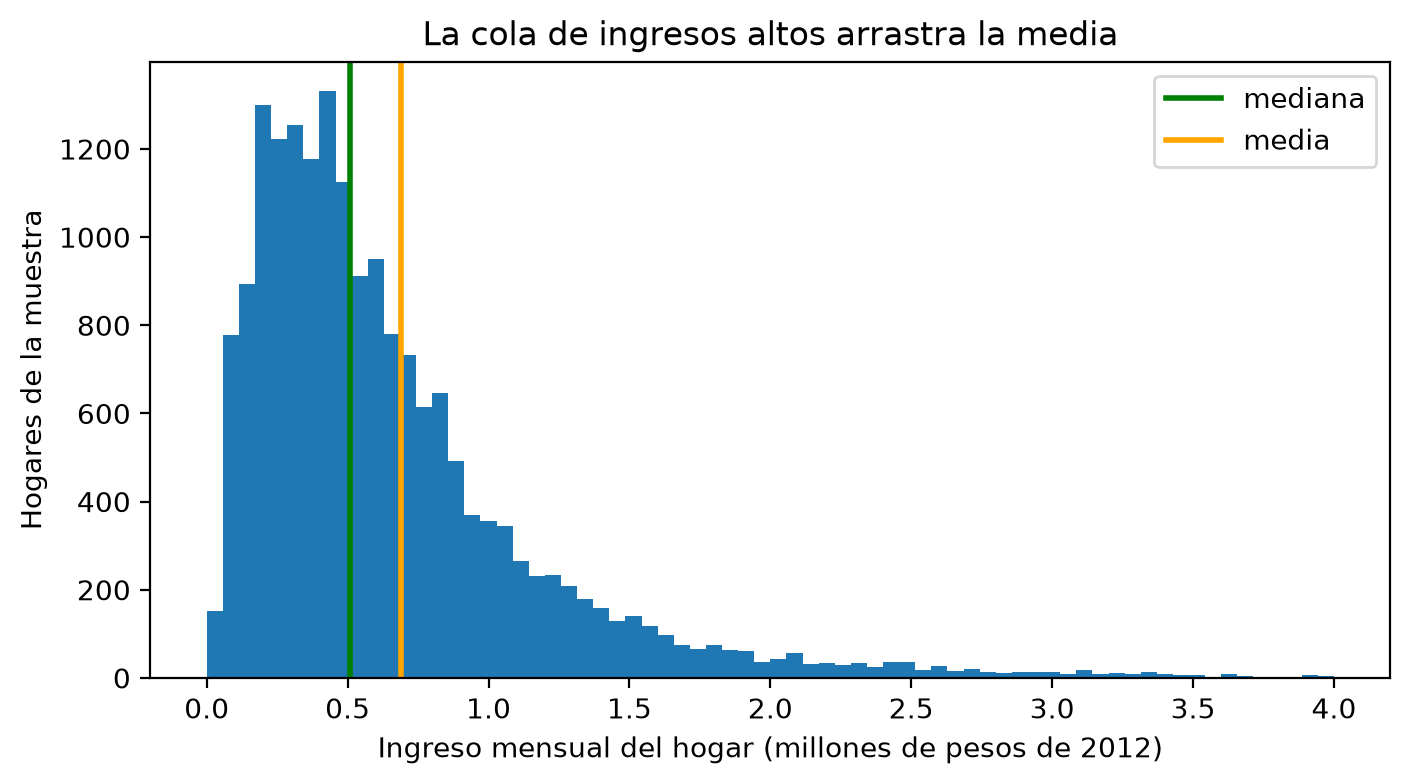

In [33]:
fig, ax = plt.subplots(figsize=(8, 4))
# Dividir por 1e6 (un millón) deja el eje en millones de pesos;
# range=(0, 4) recorta el histograma en 4 millones para ver la forma
ax.hist(ingreso / 1e6, bins=70, range=(0, 4))
ax.axvline(ingreso.median() / 1e6, color="green", lw=2, label="mediana")
ax.axvline(ingreso.mean() / 1e6, color="orange", lw=2, label="media")
ax.set_xlabel("Ingreso mensual del hogar (millones de pesos de 2012)")
ax.set_ylabel("Hogares de la muestra")
ax.set_title("La cola de ingresos altos arrastra la media")
ax.legend()
plt.show()

¿Qué tan lejos quedaron? Una forma de medirlo es dividir la media por la mediana:

In [34]:
media_ingreso = hogares["IngresoHogar"].mean()
mediana_ingreso = hogares["IngresoHogar"].median()

print("Media:   $", round(media_ingreso))
print("Mediana: $", round(mediana_ingreso))
# El cociente dice cuántas veces la mediana cabe en la media
print("Media / mediana:", round(media_ingreso / mediana_ingreso, 2))

Media:   $ 688274
Mediana: $ 507826
Media / mediana: 1.36


El cociente da 1,36: la media es 1,36 veces la mediana, es decir, queda un 36% por sobre ella ($688.274 contra $507.826). Ese exceso lo produce la cola de ingresos altos, que arrastra la media pero no mueve la mediana.

Y el mismo cuidado que con la duración: estos números describen la **muestra**. La tabla de hogares trae su factor de expansión en la columna `Factor`: cuántos hogares de la ciudad representa cada hogar encuestado. Para hablar de Santiago, la media se pondera, con la misma fórmula:

In [35]:
# Los dos ingredientes del cálculo: el ingreso y su peso
ingreso = hogares["IngresoHogar"]
factor_hogar = hogares["Factor"]

In [36]:
# Suma de (valor por peso), dividida por la suma de los pesos
media_pond_ingreso = (ingreso * factor_hogar).sum() / factor_hogar.sum()

In [37]:
print("Media de la muestra: $", round(ingreso.mean()))
print("Media ponderada:     $", round(media_pond_ingreso))
# La suma de los factores estima el total de hogares de la ciudad
print("Hogares que representa la encuesta:", round(factor_hogar.sum()))

Media de la muestra: $ 688274
Media ponderada:     $ 729898
Hogares que representa la encuesta: 2051310


La media ponderada sube a $729.898, un 6% más que en la muestra: los hogares que representan a más hogares de la ciudad tienen ingresos algo mayores que lo que la muestra sugiere. Y un dato de regalo: la suma de los factores estima el total de hogares del Gran Santiago en 2012, unos 2,05 millones.

### Dispersión

El centro no basta: falta saber cuánto se alejan los datos de él. Las cuatro medidas de la clase: el **rango** (máximo menos mínimo, frágil porque un solo valor extremo lo domina), la **varianza** (el promedio de las desviaciones al cuadrado respecto de la media), la **desviación estándar** (su raíz cuadrada, que vuelve a las unidades originales) y el **IQR** (Q3 menos Q1, el ancho de la mitad central, que no se altera con valores extremos). Para la duración de los viajes:

In [38]:
# La variable y sus dos extremos
tiempo_viaje = viajes["TiempoViaje"]
tiempo_viaje_max = tiempo_viaje.max()
tiempo_viaje_min = tiempo_viaje.min()

In [39]:
# var() es el promedio de las desviaciones al cuadrado respecto
# de la media: queda en minutos al cuadrado
varianza = tiempo_viaje.var()
varianza

np.float64(1299.6916009195768)

In [40]:
# std() es la raíz de la varianza: vuelve a minutos
desviacion = tiempo_viaje.std()
desviacion

np.float64(36.05123577520716)

In [41]:
# Las tres medidas juntas, para leerlas de una vez
print("Rango:              ", tiempo_viaje_max - tiempo_viaje_min, "minutos")
print("Varianza:           ", round(varianza, 1))
print("Desviación estándar:", round(desviacion, 1), "minutos")

Rango:               1335.0 minutos
Varianza:            1299.7
Desviación estándar: 36.1 minutos


In [42]:
# Los cuartiles con quantile; el IQR es su diferencia
q1, q3 = tiempo_viaje.quantile(0.25), tiempo_viaje.quantile(0.75)
print("Q1, Q3, IQR:", q1, q3, q3 - q1)

Q1, Q3, IQR: 15.0 50.0 35.0


In [43]:
# describe() junta casi todo lo anterior en una sola tabla
tiempo_viaje.describe().round(1)

count    113313.0
mean         36.9
std          36.1
min           0.0
25%          15.0
50%          30.0
75%          50.0
max        1335.0
Name: TiempoViaje, dtype: float64

### La media no basta

Para qué sirven estas medidas, con un ejemplo. Providencia y Talagante tienen casi la misma duración media de viaje, pero son realidades distintas. El nombre de la comuna está en la tabla de parámetros, así que primero un merge (como en la clase 1), y luego el mismo `loc` de siempre:

In [44]:
comunas = pd.read_csv(BASE + "tablas_parametros/Comunas.csv", sep=",")
viajes_comuna = viajes.merge(comunas, left_on="ComunaOrigen", right_on="Id")

# Las duraciones de los viajes que parten de cada comuna
providencia = viajes_comuna.loc[viajes_comuna["Comuna"] == "Providencia", "TiempoViaje"]
talagante = viajes_comuna.loc[viajes_comuna["Comuna"] == "Talagante", "TiempoViaje"]

In [45]:
print("Providencia | media:", round(providencia.mean(), 1),
      "| desviación:", round(providencia.std(), 1))
print("Talagante   | media:", round(talagante.mean(), 1),
      "| desviación:", round(talagante.std(), 1))

Providencia | media: 40.7 | desviación: 33.6
Talagante   | media: 40.6 | desviación: 66.6


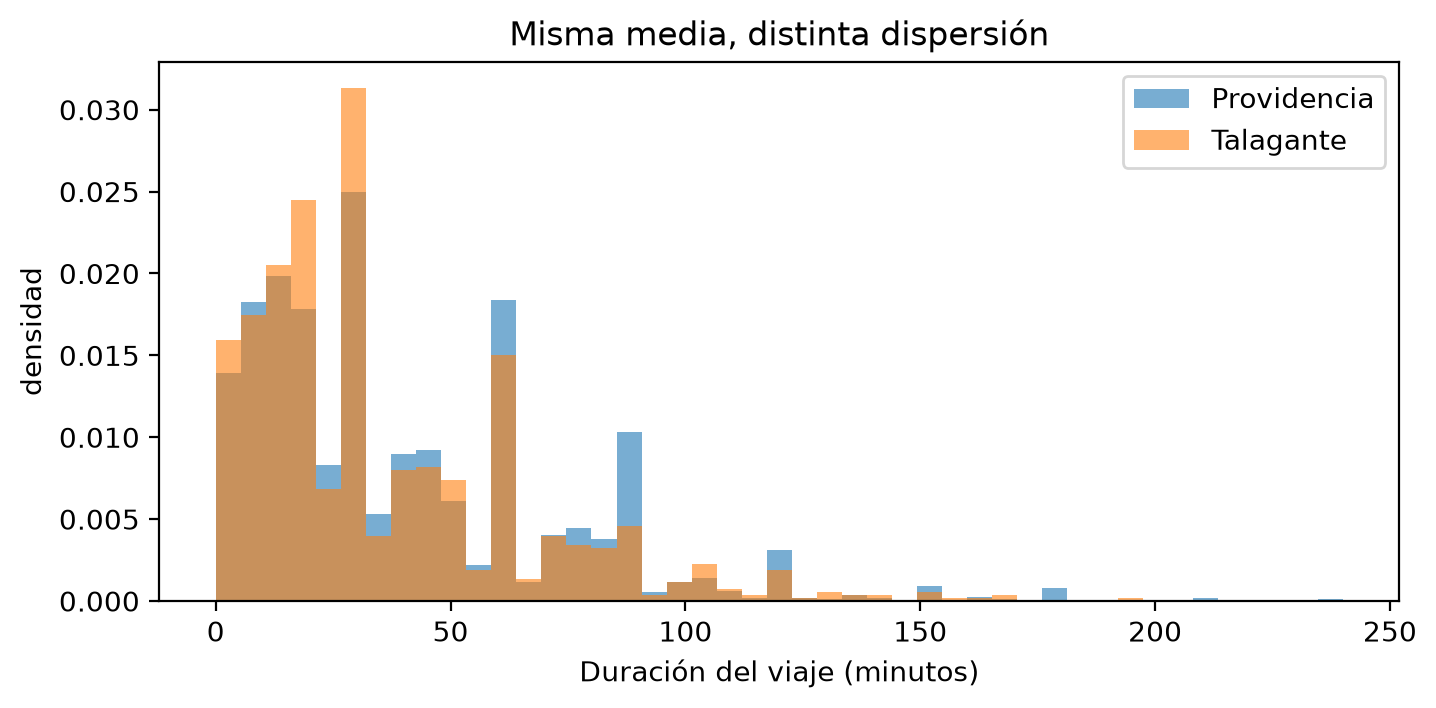

In [46]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(providencia, bins=45, range=(0, 240), density=True, alpha=0.6, label="Providencia")
ax.hist(talagante, bins=45, range=(0, 240), density=True, alpha=0.6, label="Talagante")
ax.set_xlabel("Duración del viaje (minutos)")
ax.set_ylabel("densidad")
ax.set_title("Misma media, distinta dispersión")
ax.legend()
plt.show()

La misma media, 40,7 contra 40,6 minutos, pero la desviación de Talagante (66,6) duplica la de Providencia (33,6): detrás del mismo promedio hay dos realidades distintas. Por eso el resumen de una variable siempre lleva centro **y** dispersión.

### ¿Para qué sirve el IQR?

La desviación estándar usa todos los valores, así que unos pocos extremos la inflan. El IQR solo depende de dónde caen los cuartiles, y los extremos no los mueven. Se nota al sacar los viajes de más de 300 minutos, que son apenas el 0,1% de los datos:

In [47]:
# Sacamos solo los viajes sobre 300 minutos (116 de 113.313)
sin_cola = tiempo_viaje[tiempo_viaje <= 300]

print("Desviación con todos los viajes:", round(tiempo_viaje.std(), 1))
print("Desviación sin la cola:         ", round(sin_cola.std(), 1))

Desviación con todos los viajes: 36.1
Desviación sin la cola:          31.8


In [48]:
print("IQR con todos los viajes:", tiempo_viaje.quantile(0.75) - tiempo_viaje.quantile(0.25))
print("IQR sin la cola:", sin_cola.quantile(0.75) - sin_cola.quantile(0.25))

IQR con todos los viajes: 35.0
IQR sin la cola: 35.0


Sacar el 0,1% de los datos movió la desviación estándar de 36,1 a 31,8 (un 12%); el IQR ni se enteró: sigue en 35. Para eso se usa el IQR:

1. **Reportar dispersión con colas o errores**: describe el ancho de la mitad central sin que unos pocos extremos manden en el número.
2. **Dibujar el boxplot**: el alto de la caja es exactamente el IQR.
3. **Detectar atípicos**: usando la regla de Tukey.

### Valores atípicos

La convención de Tukey marca como atípico lo que queda fuera de Q1 − 1,5·IQR y Q3 + 1,5·IQR: las mismas cercas que dibujan los bigotes del boxplot. Es una convención para marcar, no un veredicto. En la duración:

In [49]:
# Las cercas: 1,5 IQR más allá de cada cuartil
iqr = q3 - q1
corte_bajo = q1 - 1.5 * iqr
corte_alto = q3 + 1.5 * iqr
print("Límites:", corte_bajo, "y", corte_alto, "minutos")

Límites: -37.5 y 102.5 minutos


In [50]:
# Filtrar con la máscara booleana: los viajes fuera de los límites
tv = viajes["TiempoViaje"]

# Busco los valores atípicos
atipicos = tv[(tv < corte_bajo) | (tv > corte_alto)]
atipicos

1         105.0
4         150.0
25        120.0
30        110.0
80        105.0
          ...  
113502    150.0
113503    180.0
113504    150.0
113505    180.0
113521    120.0
Name: TiempoViaje, Length: 4967, dtype: float64

In [51]:
print("Viajes atípicos:", len(atipicos), "de", tv.count(),
      "|", round(len(atipicos) / tv.count() * 100, 1), "%")

Viajes atípicos: 4967 de 113313 | 4.4 %


El límite inferior queda en negativo, así que aquí solo marca la cola larga: 4.967 viajes, el 4,4%. Atípico no significa error. En iris, con la misma regla:

In [52]:
iris_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [53]:
sw = iris_df["sepal width (cm)"]
q1_sw, q3_sw = sw.quantile([0.25, 0.75])
iqr_sw = q3_sw - q1_sw

# Máscara booleana: True donde el valor queda fuera de las cercas
fuera = (sw < q1_sw - 1.5 * iqr_sw) | (sw > q3_sw + 1.5 * iqr_sw)
fuera

0      False
1      False
2      False
3      False
4      False
       ...  
145    False
146    False
147    False
148    False
149    False
Name: sepal width (cm), Length: 150, dtype: bool

In [54]:
sw[fuera]

15    4.4
32    4.1
33    4.2
60    2.0
Name: sepal width (cm), dtype: float64

Cuatro flores. En el boxplot del ancho de sépalo aparecen como puntos sueltos, fuera de los bigotes:

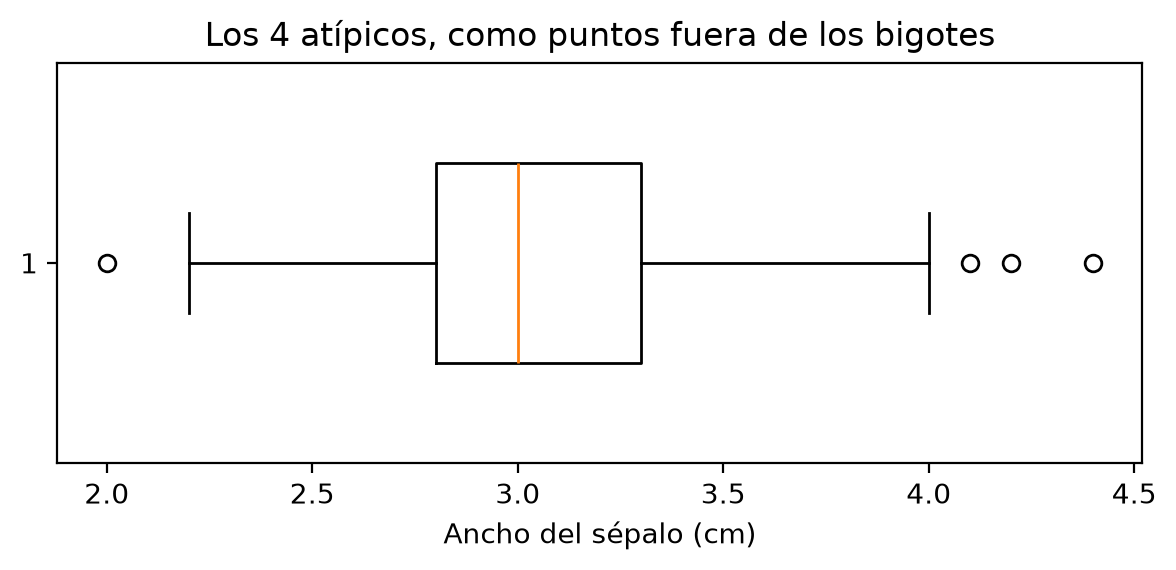

In [55]:
fig, ax = plt.subplots(figsize=(7, 2.6))
ax.boxplot(sw, orientation="horizontal", widths=0.5)
ax.set_xlabel("Ancho del sépalo (cm)")
ax.set_title("Los 4 atípicos, como puntos fuera de los bigotes")
plt.show()

Hasta el dataset más clásico tiene valores atípicos; no hay una regla universal para excluirlos.

Y el boxplot por grupo, con el modo de transporte. El modo está repartido en dos tablas (repaso de los merges de la clase 1): `ViajesDifusion.csv` trae el modo de cada viaje como código, y la tabla de parámetros `ModoDifusion.csv` traduce cada código a su nombre:

In [56]:
modo_por_viaje = pd.read_csv(BASE + "ViajesDifusion.csv", sep=";")
nombres_modo = pd.read_csv(BASE + "tablas_parametros/ModoDifusion.csv", sep=";")

# Renombramos la columna para que el nombre del modo quede claro
nombres_modo = nombres_modo.rename(columns={"ModoDifusion": "NombreModo"})
nombres_modo.head()

,ID,NombreModo
0,1,Auto
1,2,Bip!
2,3,Taxi Colectivo
3,4,Taxi
4,5,Bip! - Otros Publico


Dos merges encadenados: el primero pega a cada viaje su código de modo, y el segundo traduce ese código a su nombre:

In [57]:
viajes_modo = (viajes
    .merge(modo_por_viaje, on="Viaje")
    .merge(nombres_modo, left_on="ModoDifusion", right_on="ID"))

print(len(viajes), "viajes |", len(viajes_modo), "después de los merges")

113591 viajes | 113591 después de los merges


El modo viene muy desagregado: cada combinación con transporte público es una categoría "Bip! ..." distinta. Las agrupamos en una sola con `where` (el mnemotécnico de la clase 1: **where conserva el valor donde la condición es verdadera** y reemplaza el resto):

In [58]:
# Los nombres que NO empiezan con "Bip!" se conservan; los que
# sí, se reemplazan por la categoría agrupada
viajes_modo["ModoAgrupado"] = viajes_modo["NombreModo"].where(
    ~viajes_modo["NombreModo"].str.startswith("Bip!"),
    "Bip! (solo o combinado)")

viajes_modo["ModoAgrupado"].value_counts().head()

ModoAgrupado
Bip! (solo o combinado)    35777
Caminata                   33827
Auto                       26437
Otros                       8485
Bicicleta                   3870
Name: count, dtype: int64

Con la categoría lista, el gráfico es el mismo patrón que en iris: una lista de grupos y `ax.boxplot`. Con cinco categorías conviene la versión corta (la comprensión de lista):

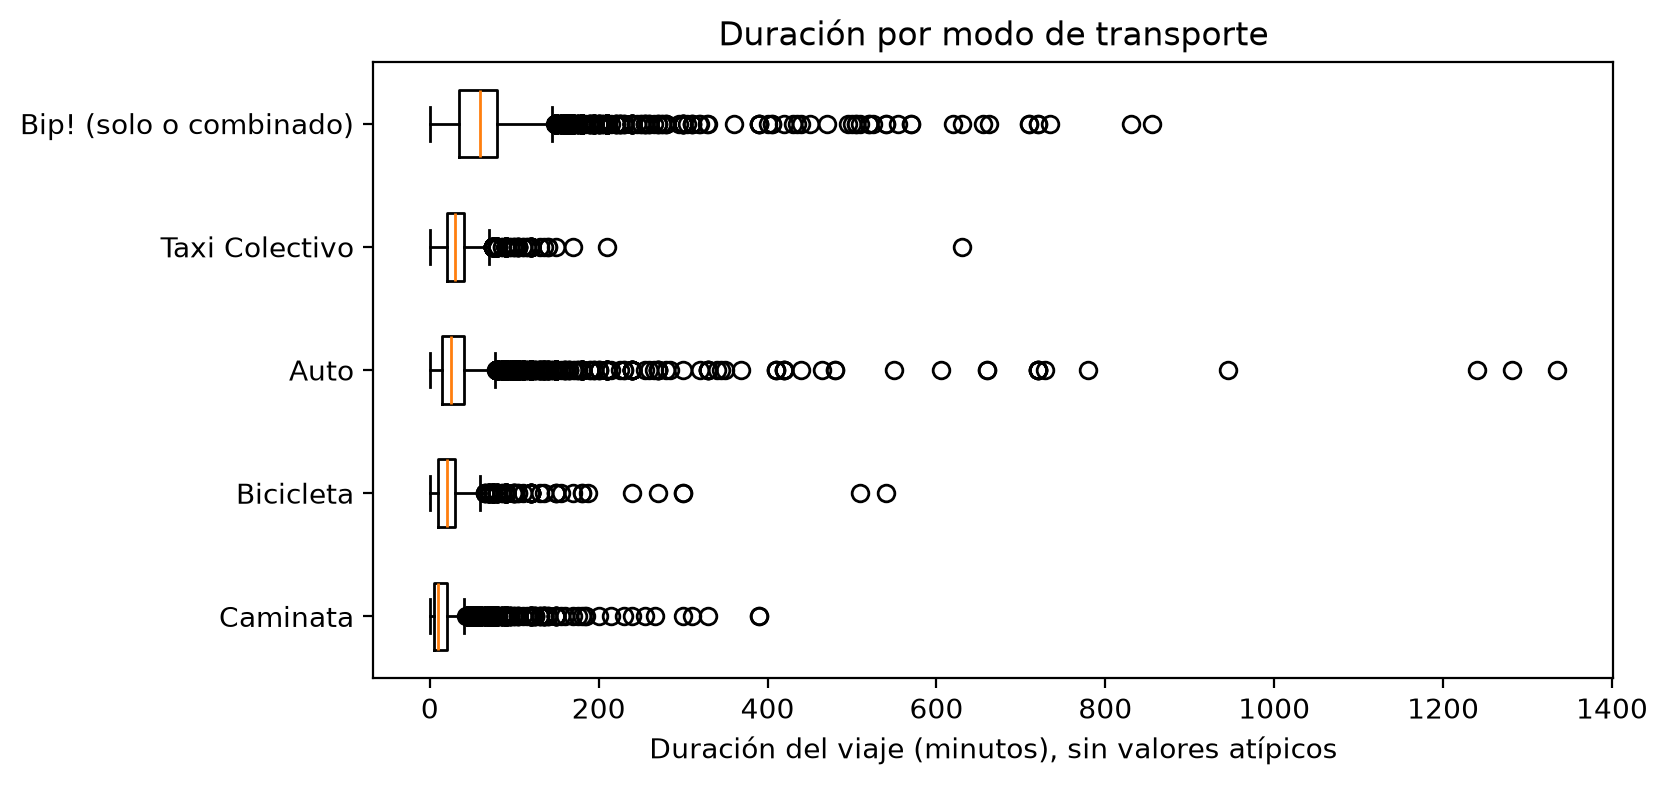

In [59]:
orden = ["Caminata", "Bicicleta", "Auto", "Taxi Colectivo",
         "Bip! (solo o combinado)"]

# El mismo loc de iris, repetido para cada modo; dropna saca los
# viajes sin duración
grupos = [viajes_modo.loc[viajes_modo["ModoAgrupado"] == m,
                          "TiempoViaje"].dropna() for m in orden]

fig, ax = plt.subplots(figsize=(8, 4))
# showfliers=False oculta los puntos atípicos, para que las cajas
# se lean sin que la cola larga aplaste la escala
ax.boxplot(grupos, orientation="horizontal", showfliers=True,
           tick_labels=orden, widths=0.55)
ax.set_xlabel("Duración del viaje (minutos), sin valores atípicos")
ax.set_title("Duración por modo de transporte")
plt.show()

## 4. Calidad de los datos

iris viene casi limpio: cero faltantes. Casi, porque hasta el dataset más famoso esconde un problema:

In [60]:
# De vuelta a iris: la tabla de nuevo a la vista
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [61]:
# isna() revisa cada celda: True donde falta el dato
iris_df.isna()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
145,False,False,False,False,False
146,False,False,False,False,False
147,False,False,False,False,False
148,False,False,False,False,False


In [62]:
# .sum() cuenta los True de cada columna
iris_df.isna().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

In [63]:
# y un segundo .sum() junta las columnas en un solo total
iris_df.isna().sum().sum()

np.int64(0)

In [64]:
# duplicated() marca las filas repetidas: todas menos la
# primera aparición
iris_df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
145    False
146    False
147    False
148    False
149    False
Length: 150, dtype: bool

In [65]:
# El resumen de calidad de iris, en dos líneas
print("Faltantes en iris: ", iris_df.isna().sum().sum())
print("Duplicados en iris:", iris_df.duplicated().sum())

Faltantes en iris:  0
Duplicados en iris: 1


Una fila duplicada en 150. En datos reales los problemas son mayores; el checklist es el mismo.

### Valores faltantes en la EOD

In [66]:
print("Filas:          ", len(viajes))
print("Con TiempoViaje:", viajes["TiempoViaje"].count())
print("Faltantes:      ", viajes["TiempoViaje"].isna().sum())

Filas:           113591
Con TiempoViaje: 113313
Faltantes:       278


278 faltantes entre 113.591. Un `NaN` no siempre es error: en los factores de expansión significa "no aplica". Las opciones (eliminar, imputar o dejar que cada cálculo excluya) son todas válidas; lo obligatorio es decidir y documentar.

### Duplicados en la EOD

In [67]:
print("Filas duplicadas:      ", viajes.duplicated().sum())
print("Ids de viaje repetidos:", viajes["Viaje"].duplicated().sum())

Filas duplicadas:       0
Ids de viaje repetidos: 0


Cero en ambos niveles: un hallazgo que descarta una fuente de error.

### Valores sospechosos

In [68]:
# nlargest(10) entrega los 10 valores más grandes de la columna,
# ordenados de mayor a menor: los diez viajes más largos declarados
viajes["TiempoViaje"].nlargest(10)

86757     1335.0
109749    1282.0
45267     1240.0
13755      945.0
27892      855.0
40207      830.0
63807      815.0
110189     815.0
109681     790.0
54524      780.0
Name: TiempoViaje, dtype: float64

In [69]:
# Los mismos diez, divididos por 60 para leerlos en horas
viajes["TiempoViaje"].nlargest(10) / 60

86757     22.250000
109749    21.366667
45267     20.666667
13755     15.750000
27892     14.250000
40207     13.833333
63807     13.583333
110189    13.583333
109681    13.166667
54524     13.000000
Name: TiempoViaje, dtype: float64

Viajes de 22, 21 y 15 horas: casi con certeza errores. Una forma de tratarlos es taparlos con `mask`, el espejo de `where`: **mask reemplaza donde la condición es verdadera**.

In [70]:
tv_limpio = tv.mask(tv > 300)

print("Media original:", round(tv.mean(), 2))
print("Media sin la cola sobre 300 min:", round(tv_limpio.mean(), 2))
print("Valores tapados:", int((tv > 300).sum()))

Media original: 36.87
Media sin la cola sobre 300 min: 36.36
Valores tapados: 116


El corte en 300 es una decisión: en un informe se justifica y se reporta cuántos valores afectó.

### Revisar cada merge

Filas antes y después, NaN de las columnas nuevas y llave única:

In [71]:
# Ojo: Comunas.csv es el único archivo de la EOD separado por coma
comunas = pd.read_csv(BASE + "tablas_parametros/Comunas.csv", sep=",")

# inner (el default) descarta las filas sin comuna en la tabla de
# parámetros; how="left" conserva todas las filas de viajes y deja
# NaN donde no hubo coincidencia
con_inner = viajes.merge(comunas, left_on="ComunaOrigen", right_on="Id")
con_left = viajes.merge(comunas, left_on="ComunaOrigen", right_on="Id", how="left")

In [72]:
con_inner.shape

(111393, 37)

In [73]:
con_left.shape

(113591, 37)

2.198 filas quedaron con NaN: son las que el inner descartaría. El conteo no basta; hay que mirar **cuáles** son. La misma máscara booleana que cuenta los NaN sirve para filtrarlos:

In [74]:
# Las filas donde el merge no encontró comuna
sin_comuna = con_left[con_left["Comuna"].isna()]

# ¿Qué códigos de origen traían esas filas?
sin_comuna["ComunaOrigen"].value_counts(dropna=False)

ComunaOrigen
0.0      1955
999.0     242
NaN         1
Name: count, dtype: int64

El misterio se resuelve: los códigos 0 y 999 no existen en la tabla de comunas (son la marca de "sin información" de la encuesta), más una fila sin código. Un NaN después de un merge siempre tiene una causa; encontrarla es parte del análisis.

---

**Próxima clase (viernes 04-sep):** pre-procesamiento y reducción de dimensión.